In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 7043 rows, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [6]:
print(f"Missing values in TotalCharges: {df['TotalCharges'].isnull().sum()}")

Missing values in TotalCharges: 11


In [7]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print()
print(churn_pct.round(1))

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


In [11]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [12]:
print(f"Missing values remaining: {df['TotalCharges'].isnull().sum()}")
print(f"Dataset shape: {df.shape}")

Missing values remaining: 0
Dataset shape: (7043, 21)


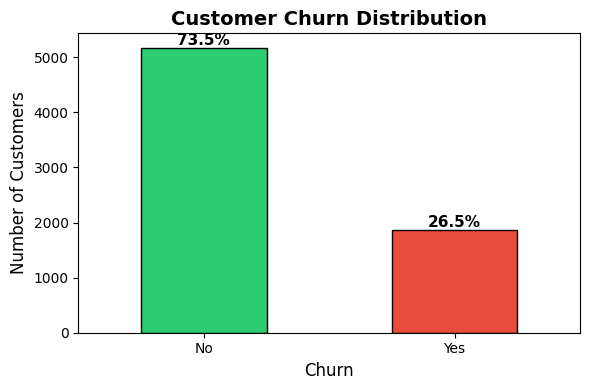

Chart saved


In [13]:
plt.figure(figsize=(6, 4))
colors = ['#2ecc71', '#e74c3c']

df['Churn'].value_counts().plot(
    kind='bar', 
    color=colors, 
    edgecolor='black',
    width=0.5
)

plt.title('Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0)

# Add percentage labels on top of each bar
total = len(df)
for i, count in enumerate(df['Churn'].value_counts()):
    plt.text(i, count + 50, f'{count/total*100:.1f}%', 
             ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/churn_distribution.png', dpi=150)
plt.show()

print("Chart saved")

## Key Finding 1
73.5% of customers did NOT churn, 26.5% did.
This class imbalance means accuracy is a misleading metric.
We will optimise for Recall instead. Catching churners matters more than avoiding false alarms.

In [14]:
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
contract_churn = contract_churn * 100

print(contract_churn.round(1))

Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8


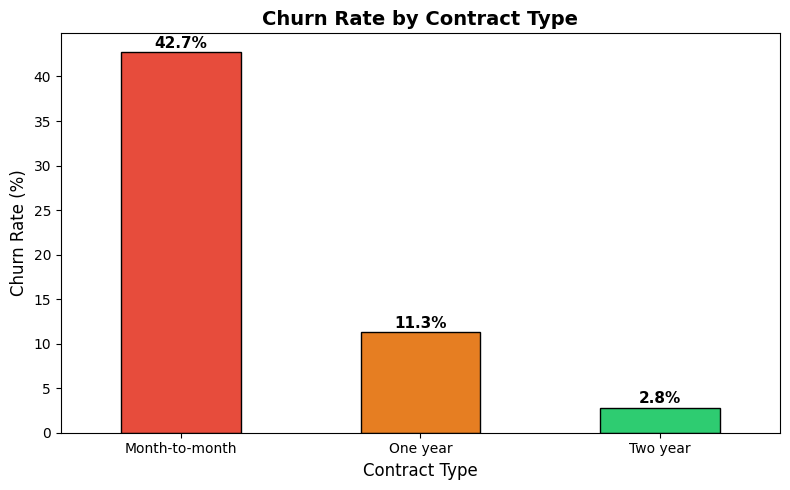

In [15]:
plt.figure(figsize=(8, 5))

contract_churn['Yes'].plot(
    kind='bar',
    color=['#e74c3c', '#e67e22', '#2ecc71'],
    edgecolor='black',
    width=0.5
)

plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xticks(rotation=0)

for i, val in enumerate(contract_churn['Yes']):
    plt.text(i, val + 0.5, f'{val:.1f}%',
             ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/churn_by_contract.png', dpi=150)
plt.show()

## Key Finding 2
Month-to-month customers churn at 42.7% vs just 2.8% for two-year contracts,
a 15x difference. These customers are the highest priority retention target.
A business intervention such as offering discounts to switch to annual contracts 
could significantly reduce overall churn.

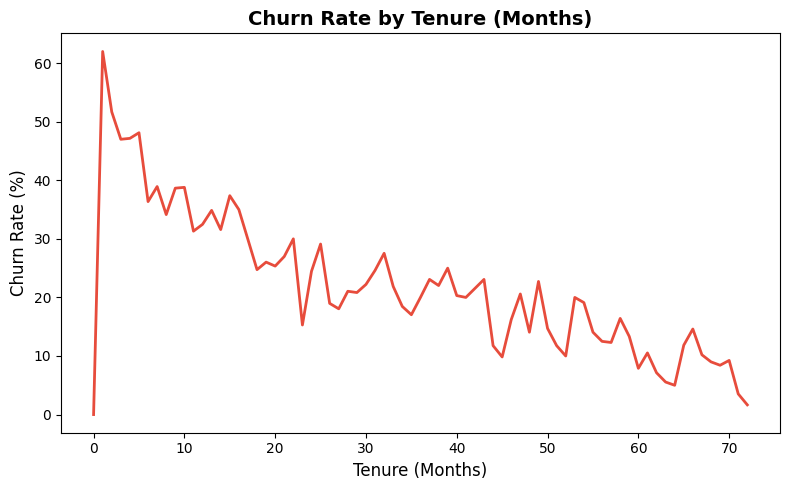

In [16]:
plt.figure(figsize=(8, 5))

df.groupby('tenure')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).plot(kind='line', color='#e74c3c', linewidth=2)

plt.title('Churn Rate by Tenure (Months)', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (Months)', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)

plt.tight_layout()
plt.savefig('../data/churn_by_tenure.png', dpi=150)
plt.show()

## Key Finding 3

Churn rate decreases sharply as tenure increases. Customers in their first 
12 months are at the highest risk of leaving. The business should focus 
retention efforts such as onboarding support, early discounts, or check-in 
calls, on new customers in their first year.

<Figure size 800x500 with 0 Axes>

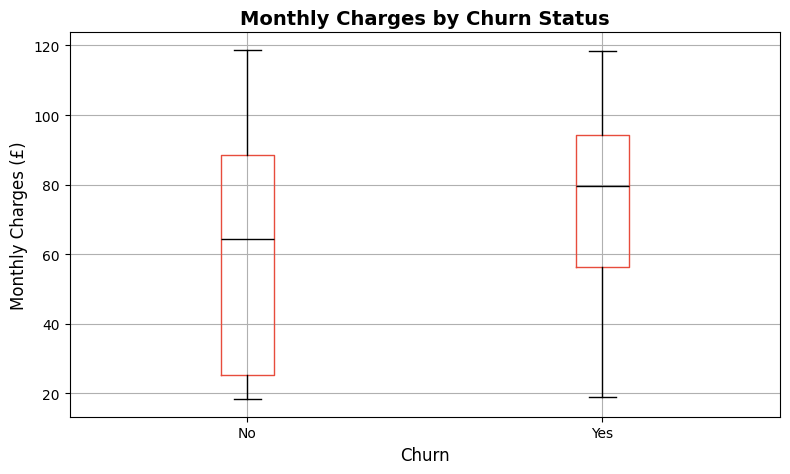

In [17]:
plt.figure(figsize=(8, 5))

df.boxplot(column='MonthlyCharges', by='Churn', 
           color=dict(boxes='#e74c3c', whiskers='black', 
                     medians='black', caps='black'),
           figsize=(8, 5))

plt.title('Monthly Charges by Churn Status', fontsize=14, fontweight='bold')
plt.suptitle('')
plt.xlabel('Churn', fontsize=12)
plt.ylabel('Monthly Charges (£)', fontsize=12)

plt.tight_layout()
plt.savefig('../data/churn_by_charges.png', dpi=150)
plt.show()

## Key Finding 4

Churned custmers have higher monthly charges than non-churned. Higher paying customers tend to leave. The business should focus on improving the service or adding additional benefits to higher paying customers.